# P.I.T.E. (Physics-informed transpiration estimates)

Using physics-informed machine learning learning on eddy covariance data to predict the transpiration ratio (T/ET)

Built using PyTorch

---

We'll start by checking the machine for GPUs
- if you have a GPU and the code is not able to find it, you may need to update your software (often NVIDIA drivers and/or CUDA toolkit)
- the model can run on a CPU if no GPU is available

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import preprocess
import boundaryconditions
import PITE

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"using device: {device}")

using device: cuda


### Now we can load in the data

The data should be formatted with FLUXNET guidelines.
- timestamps should be formatted like YYYYMMDDHHMM

For this tutorial we will be using data from US-MOz, a deciduous broadleaf forest in middle-America

In [12]:
sitedata = pd.read_csv(r"AMF_US-MOz_FLUXNET_SUBSET_HH_2004-2019_3-5.csv")
sitedata = sitedata.replace(-9999, np.nan)
#isolate 2012-2019 to shorten runtime for this example
sitedata = sitedata[sitedata['TIMESTAMP_START'] // 10**8 >= 2012].reset_index(drop=True)

## Next, we format the data for model input

Any variables with more than 30% missing data will not be used as an input feature

For feature engineering, we are calculating water use efficiency and time-lagged NEE variables

## Then, because PITE is built on a neural network, we have to scale all data

Scaled to a mean of 0 with a standard deviation of 1

In [13]:
scaledfeatures , modeldata = preprocess.featureengineering(sitedata)

# Time to build the model

---

### We can add physics into the model using differential equations

Assuming that transpiration follows a sine curve over a diel cycle, and that at somepoint during that cycle (overnight) transpiration is negligible

$$
\frac{dTET}{dt} = A * cos(\omega t + \Phi)
$$

where: A = amplitude, $\omega$ = $\frac{2\pi}{24}$, $\Phi$ = phase
with a solution of

$$
\frac{d^2 TET}{dt^2} + \omega^2 TET = 0
$$

The second derivative brings us to the simple harmonic oscillator equation which allows changing amplitudes

---

### And to ground the model in realistic values, we create boundary conditions to describe the system

Lower bound
- when NEE is positive (overnight and during fallow periods), T = 0

Upper bounds
- when the ecosystem is in its hottest and driest conditions, E = 0

Conditional inequality
- if it is precipitating, E cannot be 0

In [14]:
(x_hotanddry, y_hotanddry_target, x_fallow_t, y_fallow_target, x_pde, P_time_pde,
 threshold_p_scaled) = boundaryconditions.defineboundaries(modeldata, scaledfeatures, device)

# Run the model
---

- ensemble model, will run 10 models in parallel and take the average and standard deviation of all predictions for final output 
- can adjust how many models are including in the ensemble. more models = higher certainty = more computational time required (just change **n_models=10**)

Currently, the 10-member ensemble takes about 2 mins per year to run. If you want to shorten runtime, you can lower the number of models
- additionally, you can track the progress from the loss print outs after every 100 epochs (you can also lessen the number of epochs used in training to decrease runtime)



In [15]:
# initialize ensemble
ensemble = PITE.PINNEnsemble(input_dim=x_pde.shape[1], n_models=10, device=device)

#  x_pde requires grad for autograd or PDE calculation will fail
x_pde.requires_grad_(True)
x_hotanddry.requires_grad_(True)
x_fallow_t.requires_grad_(True)

ensemble.train_ensemble(
    x_hotanddry, y_hotanddry_target,
    x_fallow_t, y_fallow_target,
    x_pde, P_time_pde, threshold_p_scaled, 
    epochs=2000,
    lambda_ineq=1
)

# predictions with uncertainty
x_test = torch.tensor(scaledfeatures.values, dtype=torch.float32).to(device)
x_test.requires_grad_(True)
mean_predictions, std_predictions = ensemble.predict(x_test)

Epoch 0: Ensemble Avg Loss = 0.506536
    pde loss: 0.000003 | hotanddry loss: 0.256298 | fallow loss: 0.250234 | ineq loss: 0.000000

Epoch 100: Ensemble Avg Loss = 0.009362
    pde loss: 0.000467 | hotanddry loss: 0.002156 | fallow loss: 0.006739 | ineq loss: 0.000000

Epoch 200: Ensemble Avg Loss = 0.004578
    pde loss: 0.000124 | hotanddry loss: 0.000942 | fallow loss: 0.003512 | ineq loss: 0.000000

Epoch 300: Ensemble Avg Loss = 0.003443
    pde loss: 0.000061 | hotanddry loss: 0.000621 | fallow loss: 0.002759 | ineq loss: 0.000001

Epoch 400: Ensemble Avg Loss = 0.002915
    pde loss: 0.000038 | hotanddry loss: 0.000467 | fallow loss: 0.002407 | ineq loss: 0.000002

Epoch 500: Ensemble Avg Loss = 0.002606
    pde loss: 0.000026 | hotanddry loss: 0.000375 | fallow loss: 0.002201 | ineq loss: 0.000003

Epoch 600: Ensemble Avg Loss = 0.002372
    pde loss: 0.000020 | hotanddry loss: 0.000320 | fallow loss: 0.002029 | ineq loss: 0.000003

Epoch 700: Ensemble Avg Loss = 0.002159
   

## How do the predictions look?

In [22]:
x_all = torch.tensor(scaledfeatures.values, dtype=torch.float32).to(device)

# individual model stats
for i, model in enumerate(ensemble.models):
    model.eval()
    with torch.no_grad():
        y_pred = model(x_all)
    print(f'Model {i} - Max: {y_pred.max().item()}, Min: {y_pred.min().item()}, Mean: {y_pred.mean().item()}')

# ensemble stats
mean_pred, std_pred = ensemble.predict(x_all)
print(f'\nEnsemble Mean - Max: {mean_pred.max()}, Min: {mean_pred.min()}, Mean: {mean_pred.mean()}')
print(f'Ensemble Std - Mean: {std_pred.mean()}')

Model 0 - Max: 1.0, Min: 0.0, Mean: 0.14526310563087463
Model 1 - Max: 1.0, Min: 0.0, Mean: 0.10922763496637344
Model 2 - Max: 0.9999986886978149, Min: 0.0, Mean: 0.10433138906955719
Model 3 - Max: 1.0, Min: 0.0, Mean: 0.10914946347475052
Model 4 - Max: 0.9999970197677612, Min: 0.0, Mean: 0.10935413092374802
Model 5 - Max: 1.0, Min: 0.0, Mean: 0.12831227481365204
Model 6 - Max: 1.0, Min: 0.0, Mean: 0.12146539241075516
Model 7 - Max: 1.0, Min: 0.0, Mean: 0.10477165877819061
Model 8 - Max: 1.0, Min: 0.0, Mean: 0.09636800736188889
Model 9 - Max: 0.9999995231628418, Min: 0.0, Mean: 0.1090189591050148

Ensemble Mean - Max: 0.9999996423721313, Min: 0.0, Mean: 0.1137261912226677
Ensemble Std - Mean: 0.023226212710142136


## Now that we have our T/ET predictions, we can format the model output to the original dataset

In [23]:
modelindicies = scaledfeatures.index

# small df of model outputs, indexed the same way modeldata/scaledfeatures were
model_outputs = pd.DataFrame({
    'T_ratio': y_pred.cpu().numpy().flatten(),
    'T_ratio_std': std_pred.flatten()
}, index=modelindicies)

full_data = sitedata.copy()
full_data = full_data.join(model_outputs)

full_data['ET'] = full_data['LE_F_MDS'] / ((2.501 - (0.00237 * full_data['TA_F'])) * 1e+06)
full_data['ET'] = full_data['ET'].where(full_data['ET'] > 0, np.nan)
full_data['ET'] = full_data['ET'] * 60 * 30  # mm/s -> mm/HH

full_data['T_PITE'] = full_data['ET'] * full_data['T_ratio']

full_data['TIMESTAMP_START'] = pd.to_datetime(full_data['TIMESTAMP_START'], format='%Y%m%d%H%M')
full_data = full_data.set_index('TIMESTAMP_START')

# A quick look at the partitioning

Cumulative T/ET:  0.5751848701430807


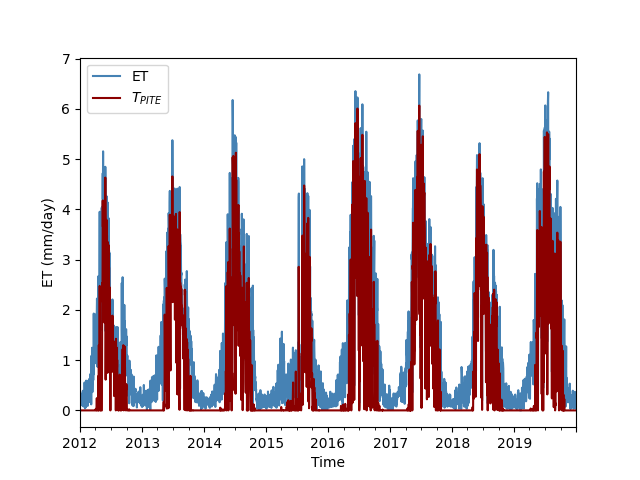

In [24]:
%matplotlib widget

fulldaily_ET = full_data['ET'].resample('D').sum()
fulldaily_T = full_data['T_PITE'].resample('D').sum()

fullcumulativeT = full_data['T_PITE'].sum()
fullcumulativeET = full_data['ET'].sum()

print("Cumulative T/ET: ", fullcumulativeT/fullcumulativeET)

fig, ax1 = plt.subplots()
fulldaily_ET.plot(ax=ax1, label='ET', color='steelblue')
fulldaily_T.plot(ax=ax1, label=r'$T_{PITE}$', color='darkred')
ax1.set_ylabel('ET (mm/day)')
ax1.set_xlabel('Time')
ax1.legend()
plt.show()

## Now we'll isolate a single year for plotting and an annual T/ET calculation

Cumulative T/ET:  0.6477246108025597


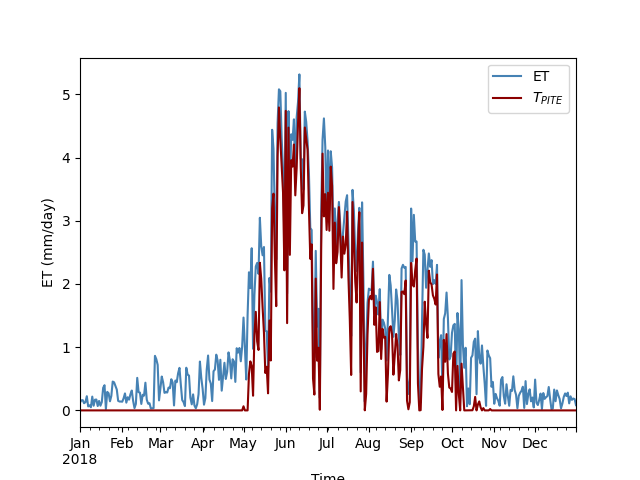

In [25]:
%matplotlib widget

plot_data = full_data.loc['2018-01-01':'2018-12-31']

daily_ET = plot_data['ET'].resample('D').sum()
daily_T = plot_data['T_PITE'].resample('D').sum()

cumulativeT = plot_data['T_PITE'].sum()
cumulativeET = plot_data['ET'].sum()

print("Cumulative T/ET: ", cumulativeT/cumulativeET)

fig, ax1 = plt.subplots()
daily_ET.plot(ax=ax1, label='ET', color='steelblue')
daily_T.plot(ax=ax1, label=r'$T_{PITE}$', color='darkred')
ax1.set_ylabel('ET (mm/day)')
ax1.set_xlabel('Time')
ax1.legend()
plt.show()

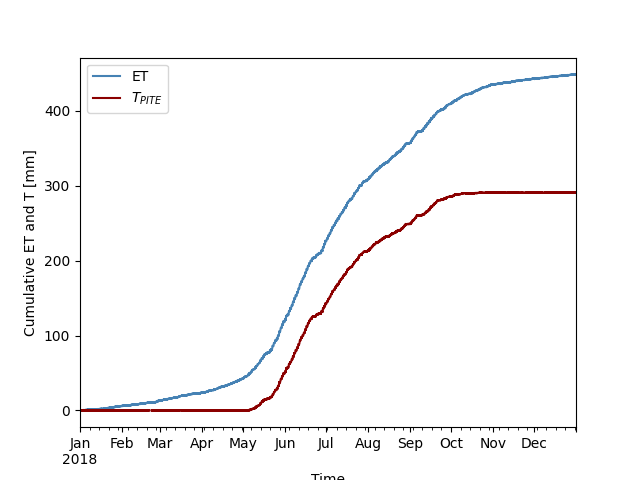

In [26]:
cumulative_ET = plot_data['ET'].cumsum()
cumulative_T = plot_data['T_PITE'].cumsum()

fig, ax1 = plt.subplots()
cumulative_ET.plot(ax=ax1, label='ET', color='steelblue')
cumulative_T.plot(ax=ax1, label=r'$T_{PITE}$', color='darkred')
ax1.set_ylabel('Cumulative ET and T [mm]')
ax1.set_xlabel('Time')
ax1.legend()
plt.show()

## Finally, we can save our output to a csv file

In [21]:
full_data.to_csv(r'PITEpartitioneddata.csv')